# 1.2 SPOC source comparison

Compare target-only training, inner-sphere Ru-AHK transfer, and outer-sphere Ru-AHK transfer to the Ru-AHO target. Evaluate 10 regression algorithms using five target folds, with mixed transfer and delta learning for each source dataset. Report pooled OOF R², MAE, and RMSE.

Plot labels are controlled in the configuration cell. The final section evaluates the pooled Ru-AHK source as an additional comparison.


In [1]:
from __future__ import annotations

import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray

from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        # Use the original font and export SVG glyphs as paths for consistent PPT rendering.
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "path",
    }
)

SOURCE_RULE_COLORS = {
    "target_only": "#B0B0B0",
    "mechanism_aligned": "#278579",
    "mechanism_mismatched": "#B56F61",
    "all_ru_ahk": "#7B61A8",
    "substrate_similar": "#009E73",
    "ligand_similar": "#E69F00",
    "reaction_feature_similar": "#56B4E9",
}
warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
PLOT_DPI = 300

# Keep result-level and feature-level caches separate.
# Recompute model predictions or SPOC descriptors only when intentionally requested.
FORCE_RECOMPUTE_RESULTS = False
FORCE_RECOMPUTE_FEATURES = False

# False: show the full diagnostic annotations.

# Shared KDE bandwidth (kcal/mol) for all three error distributions.
# The same bandwidth and x-grid are used for Target-only,
# Different-mechanism transfer, and Same-mechanism transfer.
RIDGELINE_KDE_BANDWIDTH = 0.12

# Vertical spacing and fill transparency for the three ridgelines.
RIDGELINE_VERTICAL_GAP = 1.15
RIDGELINE_FILL_ALPHA = 0.28

# Visual settings for the overlaid KDE comparison.
# This view uses the same KDE x-grid and bandwidth as the ridgeline plot.
OVERLAY_DENSITY_FILL_ALPHA = 0.14
OVERLAY_DENSITY_LINEWIDTH = 2.0

# Error-threshold summary used as a compact inset / standalone panel.
# Each bar reports the fraction of ALL OOF reactions whose absolute error
# exceeds the corresponding threshold.
ERROR_THRESHOLDS = [0.50, 1.00, 1.50]

# [left, bottom, width, height] of the threshold inset in axes coordinates.
THRESHOLD_INSET_BOUNDS = [0.56, 0.42, 0.39, 0.43]

# High-error distribution inset matching Figure 2C.
PARITY_BASELINE_COLOR = "#858585"  # Darker scatter markers only.
PARITY_BASELINE_ALPHA = 0.85
EXPORT_ERROR_DENSITY = True
ERROR_TAIL_MIN = 0.5
ERROR_TAIL_MAX = 2.5
ERROR_TAIL_N_BINS = 10
ERROR_3D_FIGSIZE = (6.6, 5.5)
ERROR_3D_ELEV = 25
ERROR_3D_AZIM = -60
ERROR_3D_LAYER_GAP = 1.05
ERROR_3D_BAR_DEPTH = 0.38
ERROR_3D_COLOR_LIGHTEN = 0.22
ERROR_3D_SHADE_STRENGTH = 0.12
ERROR_3D_DENSITY_MAX = None


# Data schema used by domain loading and feature construction.
TARGET_COLUMN = "ddG"

TARGET_COL_CANDIDATES = ["ddG", "DeltaDeltaG", "ΔΔG‡", "target", "Target", "y"]

COMPONENT_COLS = [
    "Reactant SMILES",
    "Product SMILES",
    "Ligand SMILES",
    "Solvent SMILES",
    "Additive SMILES",
]

CONDITION_COLS = ["Pressure/atm", "Temperature/C", "S/C"]


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root containing the canonical data/transfer directory."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "transfer").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DOMAIN_ROOT = PROJECT_ROOT / "data" / "transfer"
OUT_DIR = PROJECT_ROOT / "results" / "1_2_spoc_mechanism_transfer"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"

for path in [TRANSFER_DOMAIN_ROOT, OUT_DIR, TABLE_DIR, FIG_DIR, FEATURE_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

OOF_PATH = TABLE_DIR / "spoc_ru_inner_outer_to_aho_inner_oof_predictions.csv"
SCORE_PATH = TABLE_DIR / "spoc_pooled_oof_metrics_long.csv"

# Keep the output directory lean. These files were written by earlier notebook versions,
# but they are not required for result reuse or manuscript figure generation.
CLEAN_OBSOLETE_OUTPUTS = True
OBSOLETE_OUTPUT_PATHS = [
    FEATURE_CACHE_DIR / "spoc_official_like_feature_columns.csv",
    FEATURE_CACHE_DIR / "spoc_official_like_feature_metadata.json",
    FEATURE_CACHE_DIR / "spoc_official_like_descriptor_table.csv",
    TABLE_DIR / "spoc_model_parameter_audit.csv",
    TABLE_DIR / "spoc_ru_domain_summary.csv",
    TABLE_DIR / "spoc_ru_inner_outer_to_aho_inner_errors.csv",
    FIG_DIR / "spoc_selected_models_pooled_oof_R2_heatmap_0_1.png",
    FIG_DIR / "spoc_selected_models_pooled_oof_R2_heatmap_0_1.pdf",
    FIG_DIR / "spoc_selected_best_parity_plots.png",
    FIG_DIR / "spoc_selected_best_parity_plots.pdf",
]

if CLEAN_OBSOLETE_OUTPUTS:
    for obsolete_path in OBSOLETE_OUTPUT_PATHS:
        if obsolete_path.exists():
            obsolete_path.unlink()


DOMAIN_FILES = OrderedDict(
    [
        ("ru_ahk_inner", TRANSFER_DOMAIN_ROOT / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DOMAIN_ROOT / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DOMAIN_ROOT / "ru_aho_inner.csv"),
    ]
)

TRANSFER_TASKS = [
    {
        "task_id": "ru_ahk_inner_to_ru_aho_inner",
        "source_key": "ru_ahk_inner",
        "target_key": "ru_aho_inner",
        "source_domain": "inner",
        "target_domain": "inner",
        "relation_label": "Same mechanism",
        "scene_label": "Ru-AHK inner -> Ru-AHO inner",
    },
    {
        "task_id": "ru_ahk_outer_to_ru_aho_inner",
        "source_key": "ru_ahk_outer",
        "target_key": "ru_aho_inner",
        "source_domain": "outer",
        "target_domain": "inner",
        "relation_label": "Different mechanism",
        "scene_label": "Ru-AHK outer -> Ru-AHO inner",
    },
]

OOF_COLUMNS = [
    "descriptor",
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
    "fold_id",
    "target_index",
    "record_id",
    "reaction_id",
    "y_true",
    "y_pred",
]
ERROR_COLUMNS = ["model", "task_id", "method_label", "error"]


def read_csv_or_empty(path, columns=None):
    """Read a CSV cache safely, returning an empty table when the file has no parseable content."""
    if columns is None:
        columns = []
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)


def csv_has_data_rows(path, required_columns=None):
    """Return True only when a cached CSV has at least one row and the expected columns."""
    if required_columns is None:
        required_columns = []
    cache = read_csv_or_empty(path, columns=required_columns)
    if len(cache) == 0:
        return False
    missing = [col for col in required_columns if col not in cache.columns]
    return len(missing) == 0


RESULT_CACHE_AVAILABLE = csv_has_data_rows(OOF_PATH, required_columns=OOF_COLUMNS)
NEED_FEATURE_MATRICES = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

print(f"Project root: {PROJECT_ROOT}")
print(f"Transfer domain directory: {TRANSFER_DOMAIN_ROOT}")
print(f"Output directory: {OUT_DIR}")
print(f"Feature cache directory: {FEATURE_CACHE_DIR}")
print(f"Result cache available: {RESULT_CACHE_AVAILABLE}")
print(f"Feature matrices required in this run: {NEED_FEATURE_MATRICES}")

# =========================
# Figure display mode
# =========================
# Positive display switches for the publication plots. True = show.
# Axis lines, tick marks and tick numbers are retained in either mode.
SHOW_TEXT = False    # Main-text figures: titles, axis labels and annotations
SI_HEATMAP_SHOW_TEXT = True  # SI heatmap labels are independent of SHOW_TEXT
SHOW_LEGEND = False  # Legends, controlled independently of SHOW_TEXT


Project root: /home/syz/ru-mechanism-transfer
Transfer domain directory: /home/syz/ru-mechanism-transfer/data/transfer
Output directory: /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer
Feature cache directory: /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer/feature_cache
Result cache available: True
Feature matrices required in this run: False


## 1. Load the three reaction datasets

Read the curated inner-sphere Ru-AHO target and the inner- and outer-sphere Ru-AHK sources from `data/transfer/`.


In [2]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def infer_target_column(df: pd.DataFrame) -> str:
    for col in TARGET_COL_CANDIDATES:
        if col in df.columns:
            return col
    for col in df.columns:
        low = str(col).lower()
        if "ddg" in low or "delta" in low:
            return col
    raise KeyError(f"Cannot infer target column from: {list(df.columns)}")


def canonicalize_smiles(value) -> str:
    if pd.isna(value):
        return ""
    smi = str(value).strip()
    if smi == "" or smi.lower() in {"nan", "none", "null"}:
        return ""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return smi


def load_domain_table(path: Path, domain_key: str, dataset: str, mechanism_domain: str, group_label: str) -> pd.DataFrame:
    df = pd.read_csv(require_file(path)).copy()
    y_col = infer_target_column(df)
    df[TARGET_COLUMN] = pd.to_numeric(df[y_col], errors="coerce")
    df = df.loc[df[TARGET_COLUMN].notna()].reset_index(drop=True)

    for col in COMPONENT_COLS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].map(canonicalize_smiles)

    for col in CONDITION_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Metal" not in df.columns:
        df["Metal"] = "Ru"
    df["Metal"] = df["Metal"].fillna("Ru").astype(str).str.strip().str.capitalize()

    if "reaction_id" not in df.columns:
        df["reaction_id"] = [f"{domain_key}_{i:05d}" for i in range(len(df))]

    df["domain_key"] = domain_key
    df["group_key"] = domain_key
    df["group_label"] = group_label
    df["dataset"] = dataset
    df["mechanism_domain"] = mechanism_domain
    df["record_id"] = [f"{domain_key}__{i:05d}" for i in range(len(df))]
    return df


DOMAIN_SPECS = OrderedDict(
    [
        (
            "ru_ahk_inner",
            {
                "path": DOMAIN_FILES["ru_ahk_inner"],
                "domain_key": "ru_ahk_inner",
                "dataset": "AHK",
                "mechanism_domain": "inner",
                "group_label": "Source: Ru-AHK inner",
            },
        ),
        (
            "ru_ahk_outer",
            {
                "path": DOMAIN_FILES["ru_ahk_outer"],
                "domain_key": "ru_ahk_outer",
                "dataset": "AHK",
                "mechanism_domain": "outer",
                "group_label": "Source: Ru-AHK outer",
            },
        ),
        (
            "ru_aho_inner",
            {
                "path": DOMAIN_FILES["ru_aho_inner"],
                "domain_key": "ru_aho_inner",
                "dataset": "AHO",
                "mechanism_domain": "inner",
                "group_label": "Target: Ru-AHO inner",
            },
        ),
    ]
)

DOMAINS = OrderedDict((key, load_domain_table(**spec)) for key, spec in DOMAIN_SPECS.items())
ALL_DF = pd.concat(DOMAINS.values(), ignore_index=True)

DOMAIN_SUMMARY = pd.DataFrame(
    [
        {
            "domain_key": key,
            "path": str(DOMAIN_FILES[key].relative_to(PROJECT_ROOT)),
            "dataset": df["dataset"].iloc[0],
            "mechanism_domain": df["mechanism_domain"].iloc[0],
            "n_samples": len(df),
            "n_reactants": df["Reactant SMILES"].nunique(),
            "n_ligands": df["Ligand SMILES"].nunique() if "Ligand SMILES" in df.columns else np.nan,
            "ddG_mean": df[TARGET_COLUMN].mean(),
            "ddG_std": df[TARGET_COLUMN].std(),
        }
        for key, df in DOMAINS.items()
    ]
)
display(DOMAIN_SUMMARY)
print("Total samples:", len(ALL_DF))


,domain_key,path,dataset,mechanism_domain,n_samples,n_reactants,n_ligands,ddG_mean,ddG_std
0,ru_ahk_inner,data/transfer/ru_ahk_inner.csv,AHK,inner,495,214,41,2.077446,0.959506
1,ru_ahk_outer,data/transfer/ru_ahk_outer.csv,AHK,outer,1539,345,304,1.971399,0.865312
2,ru_aho_inner,data/transfer/ru_aho_inner.csv,AHO,inner,98,38,22,1.910037,0.950583


Total samples: 2132


## 2. Construct SPOC features

For each component in the order substrate, product, ligand, solvent, additive, concatenate MACCS fingerprints and RDKit descriptors. Append pressure, temperature, S/C, and categorical encodings for metal, solvent, and additive. Rebuild feature and prediction caches after changes to inputs or feature settings.


In [3]:
DESC_LIST = list(Descriptors._descList)
DESC_NAMES = [name for name, _ in DESC_LIST]
MACCS_N_BITS = 167
SPOC_DESCRIPTOR_VERSION = "spoc_official_like_maccs_rdkit_conditions_labels_v2"
SPOC_MATRIX_CACHE_PATH = FEATURE_CACHE_DIR / "spoc_official_like_feature_matrix.npy"

SPOC_COMPONENT_PREFIXES = OrderedDict(
    [
        ("Reactant SMILES", "reactant"),
        ("Product SMILES", "product"),
        ("Ligand SMILES", "ligand"),
        ("Solvent SMILES", "solvent"),
        ("Additive SMILES", "additive"),
    ]
)


def smiles_to_mol(smiles: str):
    if smiles is None or str(smiles).strip() == "":
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def maccs_array(mol) -> np.ndarray:
    arr = np.zeros((MACCS_N_BITS,), dtype=np.float32)
    if mol is None:
        return arr
    try:
        fp = MACCSkeys.GenMACCSKeys(mol)
        ConvertToNumpyArray(fp, arr)
    except Exception:
        arr[:] = np.nan
    return arr


def rdkit_descriptor_array(mol) -> np.ndarray:
    vals = []
    for _, fn in DESC_LIST:
        if mol is None:
            vals.append(np.nan)
            continue
        try:
            vals.append(float(fn(mol)))
        except Exception:
            vals.append(np.nan)
    return np.asarray(vals, dtype=np.float32)


def build_component_spoc(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
    maccs_rows = []
    desc_rows = []
    for smi in df[col].astype(str).tolist():
        mol = smiles_to_mol(smi)
        maccs_rows.append(maccs_array(mol))
        desc_rows.append(rdkit_descriptor_array(mol))

    maccs_df = pd.DataFrame(
        np.vstack(maccs_rows),
        columns=[f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_N_BITS)],
        index=df.index,
    )
    desc_df = pd.DataFrame(
        np.vstack(desc_rows),
        columns=[f"{prefix}__RDKit_{name}" for name in DESC_NAMES],
        index=df.index,
    )
    return pd.concat([maccs_df, desc_df], axis=1)


def expected_spoc_feature_columns(df: pd.DataFrame) -> list[str]:
    columns = []
    for _, prefix in SPOC_COMPONENT_PREFIXES.items():
        columns.extend([f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_N_BITS)])
        columns.extend([f"{prefix}__RDKit_{name}" for name in DESC_NAMES])

    columns.extend([f"condition__{col}" for col in CONDITION_COLS])

    label_columns = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    ).columns.astype(str).tolist()
    columns.extend(label_columns)
    return columns


def build_spoc_matrix(df: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    pieces = []
    for col, prefix in SPOC_COMPONENT_PREFIXES.items():
        print(f"Building SPOC component descriptors: {prefix}")
        pieces.append(build_component_spoc(df, col, prefix))

    # Numeric reaction conditions are included directly and imputed inside CV pipelines.
    condition_df = df[CONDITION_COLS].apply(pd.to_numeric, errors="coerce")
    condition_df.columns = [f"condition__{c}" for c in condition_df.columns]
    pieces.append(condition_df)

    # Reaction-context labels: keep them light and reproducible.
    label_df = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    )
    pieces.append(label_df)

    x_df = pd.concat(pieces, axis=1).replace([np.inf, -np.inf], np.nan)
    return x_df.to_numpy(dtype=np.float32), list(x_df.columns)


def load_cached_spoc_matrix(expected_columns: list[str]):
    if FORCE_RECOMPUTE_FEATURES or not SPOC_MATRIX_CACHE_PATH.exists():
        return None, None
    try:
        matrix = np.load(SPOC_MATRIX_CACHE_PATH)
        expected_shape = (len(ALL_DF), len(expected_columns))
        if matrix.shape != expected_shape:
            print(f"Cached SPOC matrix has shape {matrix.shape}, expected {expected_shape}; rebuilding.")
            return None, None
        print(f"Loaded cached SPOC features: {matrix.shape}")
        return matrix.astype(np.float32, copy=False), expected_columns
    except Exception as exc:
        print(f"Could not load cached SPOC features: {exc!r}; rebuilding.")
        return None, None


def save_cached_spoc_matrix(matrix):
    matrix = matrix.astype(np.float32, copy=False)
    np.save(SPOC_MATRIX_CACHE_PATH, matrix)
    print(f"Saved SPOC feature cache: {SPOC_MATRIX_CACHE_PATH}")


TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())
TARGET_META = OrderedDict(
    (
        key,
        df[["record_id", "reaction_id", "domain_key", "group_key"]].reset_index(drop=True),
    )
    for key, df in DOMAINS.items()
)
FEATURES = OrderedDict()

if NEED_FEATURE_MATRICES:
    EXPECTED_FEATURE_COLUMNS = expected_spoc_feature_columns(ALL_DF)
    X_MATRIX, FEATURE_COLUMNS = load_cached_spoc_matrix(EXPECTED_FEATURE_COLUMNS)
    if X_MATRIX is None:
        print(f"Building SPOC features for all Ru domains: {len(ALL_DF)} rows")
        X_MATRIX, FEATURE_COLUMNS = build_spoc_matrix(ALL_DF)
        if FEATURE_COLUMNS != EXPECTED_FEATURE_COLUMNS:
            raise RuntimeError("Reconstructed SPOC feature columns do not match the freshly built columns.")
        save_cached_spoc_matrix(X_MATRIX)

    start = 0
    for key, df in DOMAINS.items():
        stop = start + len(df)
        FEATURES[key] = X_MATRIX[start:stop].astype(np.float32, copy=False)
        start = stop

    print("X shape:", X_MATRIX.shape)
    print("NaN count:", int(np.isnan(X_MATRIX).sum()))
    display(pd.DataFrame(X_MATRIX[:3], columns=FEATURE_COLUMNS).iloc[:, :12])
else:
    print("OOF predictions are already cached. SPOC feature matrix is not loaded in this run.")


OOF predictions are already cached. SPOC feature matrix is not loaded in this run.


## 3. Regression algorithms

Use the 10 algorithms defined below. Scale features for GPR, KNN, SVR, and LinearSVR. Apply mean imputation before each SPOC estimator.


In [4]:
SPOC_MODEL_FACTORIES = OrderedDict(
    [
        (
            "ExtraTreesRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE),
            ),
        ),
        (
            "GradientBoostingRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                GradientBoostingRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "HistGradientBoostingRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "RandomForestRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
            ),
        ),
        (
            "GaussianProcessRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                GaussianProcessRegressor(
                    normalize_y=True,
                    alpha=1e-6,
                    random_state=RANDOM_STATE,
                ),
            ),
        ),
        (
            "KNeighborsRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                KNeighborsRegressor(),
            ),
        ),
        (
            "SVR",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                SVR(),
            ),
        ),
        (
            "LinearSVR",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                LinearSVR(random_state=RANDOM_STATE, max_iter=5000),
            ),
        ),
        (
            "DecisionTreeRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                DecisionTreeRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "ExtraTreeRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                ExtraTreeRegressor(random_state=RANDOM_STATE),
            ),
        ),
    ]
)


MODEL_KEYS_TO_RUN = list(SPOC_MODEL_FACTORIES.keys())

MODEL_AUDIT_DF = pd.DataFrame(
    [
        {
            "model": model_key,
            "factory_repr": repr(SPOC_MODEL_FACTORIES[model_key]()),
        }
        for model_key in MODEL_KEYS_TO_RUN
    ]
)
display(MODEL_AUDIT_DF)


,model,factory_repr
0,ExtraTreesRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
1,GradientBoostingRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
2,HistGradientBoostingRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
3,RandomForestRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
4,GaussianProcessRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
5,KNeighborsRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
6,SVR,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
7,LinearSVR,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
8,DecisionTreeRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
9,ExtraTreeRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."


## 4. Five-fold evaluation

Use the same target folds for target-only, mixed-transfer, and delta-learning models. Pool held-out predictions to calculate metrics. Existing prediction tables are reused unless recomputation is requested.


In [5]:
def make_model(model_key):
    return SPOC_MODEL_FACTORIES[model_key]()


def predict_1d(model, x):
    pred = np.asarray(model.predict(x)).reshape(-1)
    return pred.astype(float)


def kfold_splitter(y_target):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def run_target_only_oof(model_key, x_target, y_target, target_meta):
    rows = []
    cv = kfold_splitter(y_target)
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        model = make_model(model_key)
        model.fit(x_target[train_idx], y_target[train_idx])
        pred = predict_1d(model, x_target[test_idx])
        fold_meta = target_meta.iloc[test_idx].reset_index(drop=True)

        for i, local_idx in enumerate(test_idx):
            rows.append(
                {
                    "descriptor": "SPOC_official_like",
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "scene_label": "Ru-AHO inner target-only",
                    "source_domain": "none",
                    "target_domain": "inner",
                    "relation_label": "Target-only",
                    "method_label": "Target-only",
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "record_id": fold_meta.loc[i, "record_id"],
                    "reaction_id": fold_meta.loc[i, "reaction_id"],
                    "y_true": float(y_target[local_idx]),
                    "y_pred": float(pred[i]),
                }
            )
    return rows


def run_transfer_oof(model_key, task, x_source, y_source, x_target, y_target, target_meta):
    rows = []
    cv = kfold_splitter(y_target)

    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]
        fold_meta = target_meta.iloc[test_idx].reset_index(drop=True)

        mixed_model = make_model(model_key)
        x_mixed = np.vstack([x_source, x_train])
        y_mixed = np.concatenate([y_source, y_train])
        mixed_model.fit(x_mixed, y_mixed)
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior_model, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)

        prediction_map = OrderedDict(
            [
                ("Mixed transfer", pred_mixed),
                ("Delta learning", pred_delta),
            ]
        )

        for method_label, pred in prediction_map.items():
            for i, local_idx in enumerate(test_idx):
                rows.append(
                    {
                        "descriptor": "SPOC_official_like",
                        "model": model_key,
                        "task_id": task["task_id"],
                        "scene_label": task["scene_label"],
                        "source_domain": task["source_domain"],
                        "target_domain": task["target_domain"],
                        "relation_label": task["relation_label"],
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(local_idx),
                        "record_id": fold_meta.loc[i, "record_id"],
                        "reaction_id": fold_meta.loc[i, "reaction_id"],
                        "y_true": float(y_test[i]),
                        "y_pred": float(pred[i]),
                    }
                )
    return rows


RUN_MODELS = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

if not RUN_MODELS:
    MULTI_MODEL_OOF_DF = read_csv_or_empty(OOF_PATH, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(columns=ERROR_COLUMNS)
    print(f"Loaded cached OOF predictions from {OOF_PATH}")
else:
    if not FEATURES:
        raise RuntimeError(
            "Feature matrices are required for recomputation but were not built. "
            "Set FORCE_RECOMPUTE_RESULTS=False to use cached predictions, or rerun the feature-cache cell."
        )

    all_rows = []
    error_rows = []
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    target_meta = TARGET_META["ru_aho_inner"]

    for model_key in MODEL_KEYS_TO_RUN:
        print(f"Running {model_key}")
        try:
            all_rows.extend(run_target_only_oof(model_key, x_target, y_target, target_meta))
        except Exception as exc:
            error_rows.append(
                {
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "method_label": "Target-only",
                    "error": repr(exc),
                }
            )
            print(f"  Target-only failed for {model_key}: {exc!r}")

        for task in TRANSFER_TASKS:
            try:
                source_key = task["source_key"]
                all_rows.extend(
                    run_transfer_oof(
                        model_key,
                        task,
                        FEATURES[source_key],
                        TARGETS[source_key],
                        x_target,
                        y_target,
                        target_meta,
                    )
                )
            except Exception as exc:
                error_rows.append(
                    {
                        "model": model_key,
                        "task_id": task["task_id"],
                        "method_label": "transfer",
                        "error": repr(exc),
                    }
                )
                print(f"  Transfer failed for {model_key}, {task['task_id']}: {exc!r}")

    MULTI_MODEL_OOF_DF = pd.DataFrame(all_rows, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(error_rows, columns=ERROR_COLUMNS)
    MULTI_MODEL_OOF_DF.to_csv(OOF_PATH, index=False)

print(f"OOF prediction rows: {len(MULTI_MODEL_OOF_DF)}")
if len(ERROR_DF):
    print("Some model-task combinations failed. The errors are shown below and are not written to disk.")
    display(ERROR_DF)


Loaded cached OOF predictions from /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer/tables/spoc_ru_inner_outer_to_aho_inner_oof_predictions.csv
OOF prediction rows: 4900


## 5. Metrics and figures

Export pooled OOF metrics, model-comparison heatmaps, and prediction-error plots. High-error histogram densities use the total number of predictions and the full bin width.


,descriptor,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total
26,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.702908,0.352521,0.515476,98
11,SPOC_official_like,ExtraTreesRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.681813,0.367103,0.533463,98
41,SPOC_official_like,RandomForestRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.664338,0.390338,0.547916,98
43,SPOC_official_like,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.649806,0.394406,0.559651,98
27,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Delta learning,0.637656,0.434750,0.569277,98
20,SPOC_official_like,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.636471,0.398876,0.570207,98
21,SPOC_official_like,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.630314,0.414097,0.575015,98
24,SPOC_official_like,GradientBoostingRegressor,target_only_ru_aho_inner,Ru-AHO inner target-only,none,inner,Target-only,Target-only,0.621655,0.405804,0.581710,98
42,SPOC_official_like,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Delta learning,0.617635,0.412007,0.584793,98
28,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.616949,0.417863,0.585317,98


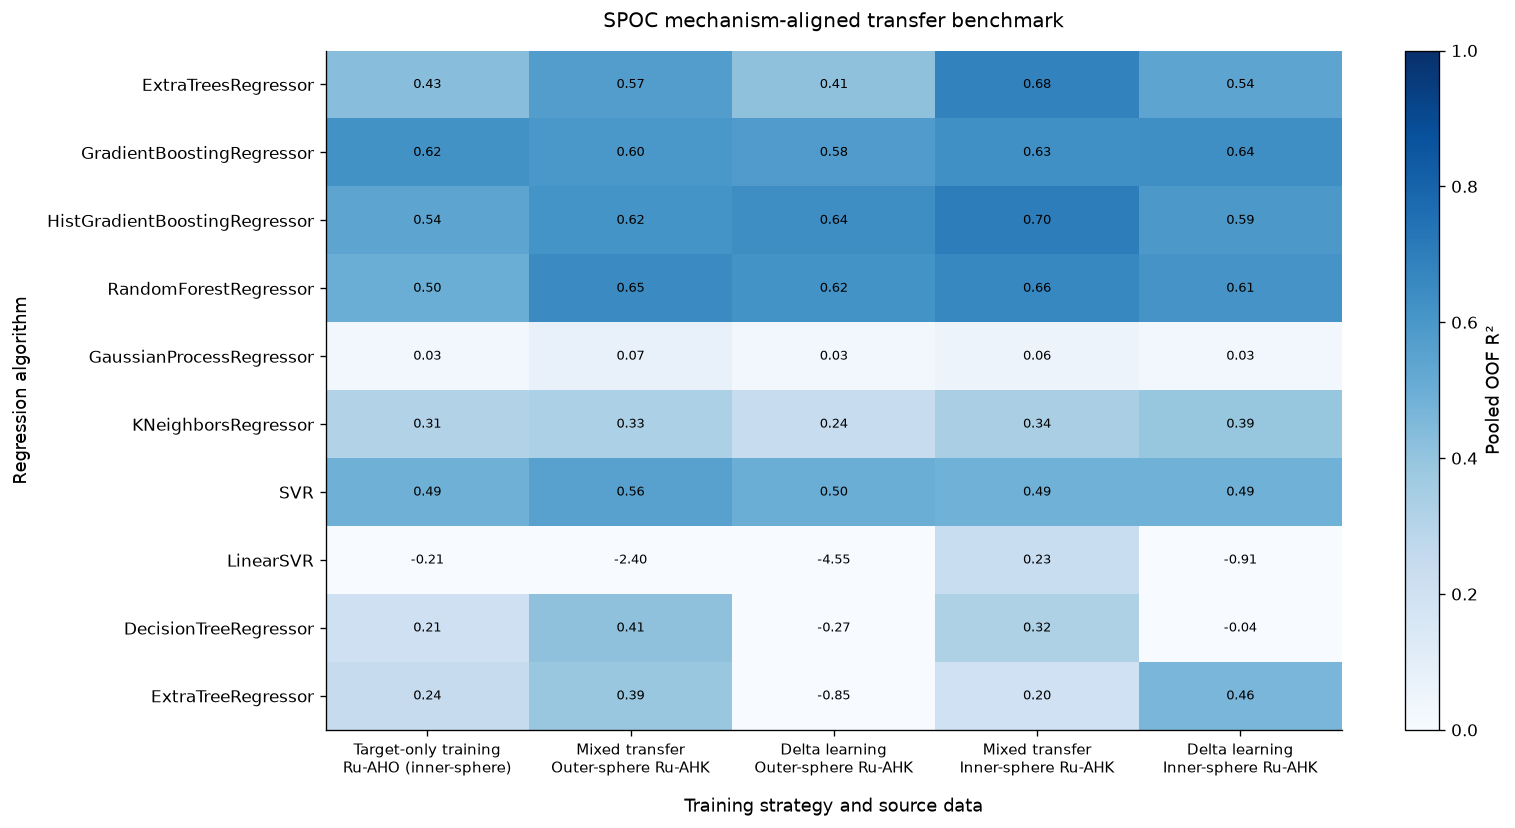

In [6]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }


GROUP_COLUMNS = [
    "descriptor",
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
]

metric_rows = []
for keys, group in MULTI_MODEL_OOF_DF.groupby(GROUP_COLUMNS, dropna=False):
    row = dict(zip(GROUP_COLUMNS, keys))
    row.update(pooled_metrics(group["y_true"].to_numpy(), group["y_pred"].to_numpy()))
    metric_rows.append(row)

MULTI_MODEL_SCORE_LONG = pd.DataFrame(metric_rows)
MULTI_MODEL_SCORE_LONG.to_csv(SCORE_PATH, index=False)
display(MULTI_MODEL_SCORE_LONG.sort_values("R2", ascending=False))


def plot_column_label(row):
    if row["method_label"] == "Target-only":
        return "Target-only\nRu-AHO inner"
    method_short = {"Mixed transfer": "Mixed", "Delta learning": "Delta"}.get(
        row["method_label"], row["method_label"]
    )
    source_short = "AHK inner" if row["source_domain"] == "inner" else "AHK outer"
    return f"{source_short} -> AHO inner\n{method_short}"


plot_score = MULTI_MODEL_SCORE_LONG.copy()
plot_score["plot_col"] = plot_score.apply(plot_column_label, axis=1)

# Keep the full benchmark heatmap, but place different-mechanism transfer
# before same-mechanism transfer throughout the figure.
HEATMAP_COLUMN_ORDER = [
    "Target-only\nRu-AHO inner",
    "AHK outer -> AHO inner\nMixed",
    "AHK outer -> AHO inner\nDelta",
    "AHK inner -> AHO inner\nMixed",
    "AHK inner -> AHO inner\nDelta",
]

R2_HEATMAP = (
    plot_score.pivot_table(index="model", columns="plot_col", values="R2", aggfunc="mean")
    .reindex(index=MODEL_KEYS_TO_RUN)
    .reindex(columns=[col for col in HEATMAP_COLUMN_ORDER if col in plot_score["plot_col"].unique()])
)
R2_HEATMAP.to_csv(TABLE_DIR / "spoc_pooled_oof_r2_heatmap_table.csv")


def plot_annotated_heatmap(table, out_path, title, cbar_label="Pooled OOF R²", show_text=None):
    # SI output keeps labels even when the main-text figures omit text.
    if show_text is None:
        show_text = globals().get("SI_HEATMAP_SHOW_TEXT", True)
    values = table.to_numpy(dtype=float)
    color_values = np.clip(values, 0.0, 1.0)
    masked_values = np.ma.masked_invalid(color_values)

    fig_w = max(12.0, 1.8 * table.shape[1] + 4.5)
    fig_h = max(6.5, 0.48 * table.shape[0] + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(masked_values, aspect="auto", cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(table.shape[1]))
    column_labels = {
        "Target-only\nRu-AHO inner": "Target-only training\nRu-AHO (inner-sphere)",
        "AHK outer -> AHO inner\nMixed": "Mixed transfer\nOuter-sphere Ru-AHK",
        "AHK outer -> AHO inner\nDelta": "Delta learning\nOuter-sphere Ru-AHK",
        "AHK inner -> AHO inner\nMixed": "Mixed transfer\nInner-sphere Ru-AHK",
        "AHK inner -> AHO inner\nDelta": "Delta learning\nInner-sphere Ru-AHK",
    }
    labels = [column_labels.get(col, str(col)) for col in table.columns]
    ax.set_xticklabels(labels if show_text else ["" for _ in labels], rotation=0, ha="center", fontsize=9)
    ax.set_xlabel("Training strategy and source data" if show_text else "", labelpad=12)
    ax.set_ylabel("Regression algorithm" if show_text else "", labelpad=10)
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index if show_text else ["" for _ in table.index], fontsize=10)
    ax.set_title(title if show_text else "", pad=14)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j,
                    i,
                    f"{float(value):.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label if show_text else "")
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


# Original full heatmap retained.
plot_annotated_heatmap(
    R2_HEATMAP,
    FIG_DIR / "spoc_selected_models_pooled_oof_R2_heatmap_0_1.svg",
    "SPOC mechanism-aligned transfer benchmark",
    "Pooled OOF R²",
)


# Compact heatmap for the main-text comparison.
# Mixed transfer and delta learning are collapsed by taking the higher R2
# within each mechanism relation for each model.


,descriptor,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total,display_name,selection,point_color
0,SPOC_official_like,GradientBoostingRegressor,target_only_ru_aho_inner,Ru-AHO inner target-only,none,inner,Target-only,Target-only,0.621655,0.405804,0.581710,98,Best target-only baseline,baseline,#B0B0B0
1,SPOC_official_like,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.649806,0.394406,0.559651,98,Best different-mechanism transfer,different_mechanism_transfer,#B56F61
2,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.702908,0.352521,0.515476,98,Best same-mechanism transfer,same_mechanism_transfer,#278579


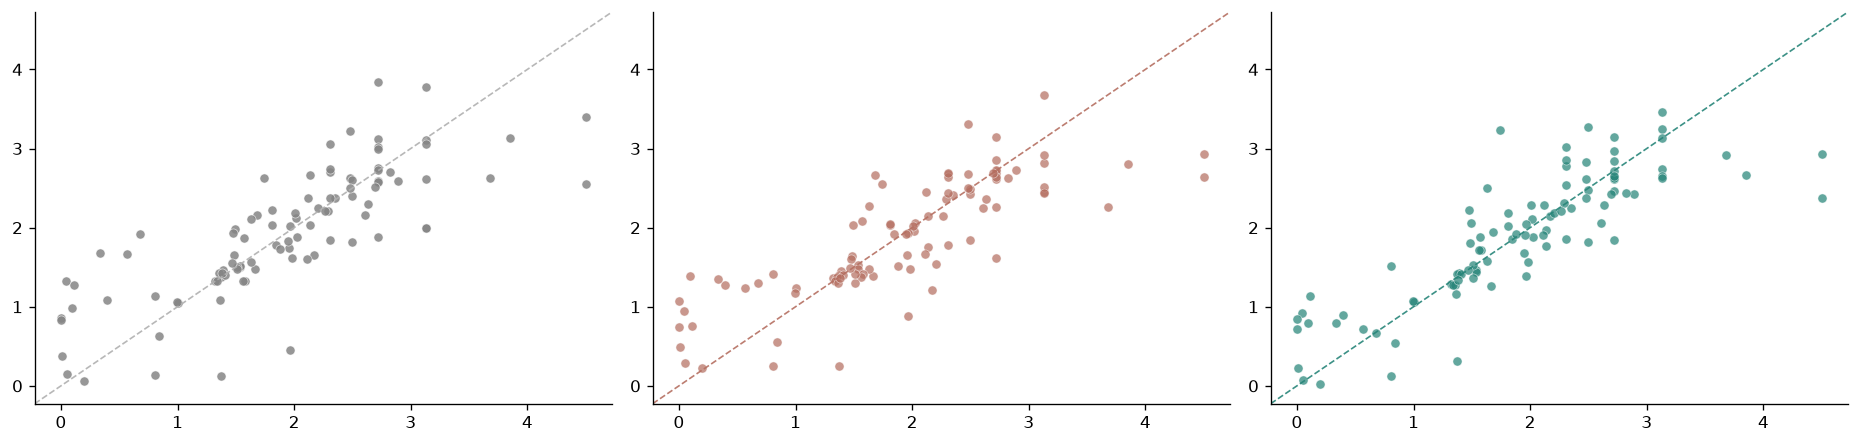

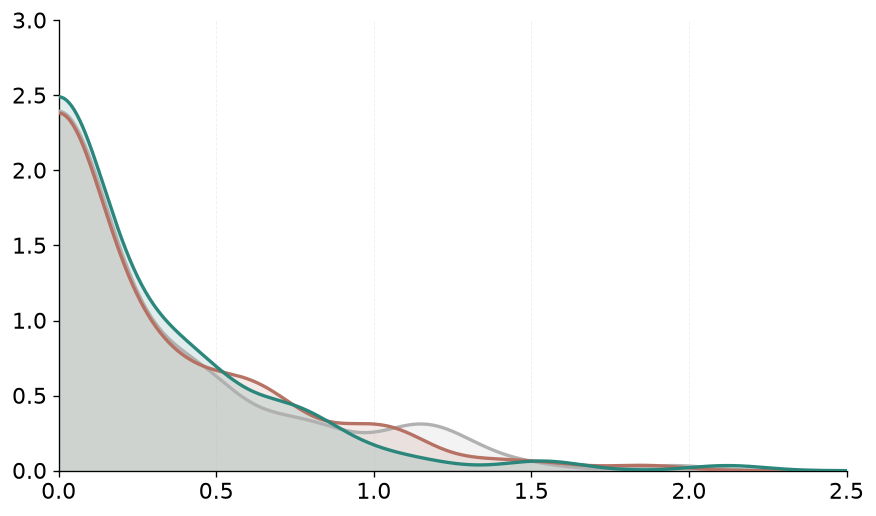

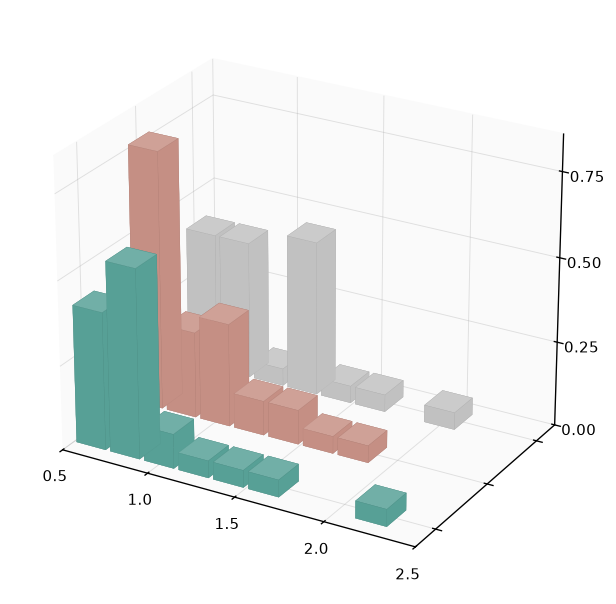

In [7]:
def select_best_score_row(score_long, selection):
    if selection == "baseline":
        sub = score_long.loc[score_long["method_label"].eq("Target-only")].copy()
    elif selection == "same_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Same mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    elif selection == "different_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Different mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    else:
        raise ValueError(selection)

    if len(sub) == 0:
        raise ValueError(f"No rows found for selection={selection!r}")
    return sub.sort_values("R2", ascending=False).iloc[0]


# Keep the presentation order consistent across all figures:
# Target-only -> Different-mechanism transfer -> Same-mechanism transfer.
# Shared palette: light gray target, terracotta mismatched, teal aligned.
PARITY_SELECTION_STYLES = OrderedDict(
    [
        (
            "baseline",
            {
                "display_name": "Best target-only baseline",
                "point_color": SOURCE_RULE_COLORS["target_only"],
            },
        ),
        (
            "different_mechanism_transfer",
            {
                "display_name": "Best different-mechanism transfer",
                "point_color": SOURCE_RULE_COLORS["mechanism_mismatched"],
            },
        ),
        (
            "same_mechanism_transfer",
            {
                "display_name": "Best same-mechanism transfer",
                "point_color": SOURCE_RULE_COLORS["mechanism_aligned"],
            },
        ),
    ]
)


SELECTED_ROWS = []
for selection, style in PARITY_SELECTION_STYLES.items():
    row = select_best_score_row(MULTI_MODEL_SCORE_LONG, selection)
    item = row.to_dict()
    item["display_name"] = style["display_name"]
    item["selection"] = selection
    item["point_color"] = style["point_color"]
    SELECTED_ROWS.append(item)

SELECTED_OUTCOME_DF = pd.DataFrame(SELECTED_ROWS)
SELECTED_OUTCOME_DF.to_csv(
    TABLE_DIR / "spoc_selected_best_outcomes_for_parity.csv", index=False
)
display(SELECTED_OUTCOME_DF)


def get_oof_predictions_for_selected(row):
    mask = (
        MULTI_MODEL_OOF_DF["model"].eq(row["model"])
        & MULTI_MODEL_OOF_DF["task_id"].eq(row["task_id"])
        & MULTI_MODEL_OOF_DF["method_label"].eq(row["method_label"])
    )
    pred = MULTI_MODEL_OOF_DF.loc[mask].copy()
    if len(pred) == 0:
        raise ValueError(
            f"Cannot find OOF predictions for selected outcome: {row.to_dict()}"
        )
    return pred


def metrics_from_prediction_df(pred):
    return pooled_metrics(
        pred["y_true"].to_numpy(),
        pred["y_pred"].to_numpy(),
    )


def plot_parity_panel(ax, pred, title, subtitle, point_color):
    y_true = pred["y_true"].to_numpy(dtype=float)
    y_pred = pred["y_pred"].to_numpy(dtype=float)
    metric = metrics_from_prediction_df(pred)

    is_baseline = str(point_color).lower() == str(PARITY_SELECTION_STYLES["baseline"]["point_color"]).lower()
    ax.scatter(
        y_true,
        y_pred,
        s=30,
        alpha=PARITY_BASELINE_ALPHA if is_baseline else 0.72,
        color=PARITY_BASELINE_COLOR if is_baseline else point_color,
        edgecolors="white",
        linewidths=0.35,
    )

    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    if finite.any():
        lo = float(np.nanmin([y_true[finite].min(), y_pred[finite].min()]))
        hi = float(np.nanmax([y_true[finite].max(), y_pred[finite].max()]))
        pad = 0.05 * (hi - lo) if hi > lo else 0.5
        lo -= pad
        hi += pad

        ax.plot(
            [lo, hi],
            [lo, hi],
            linestyle="--",
            linewidth=1.0,
            color=point_color,
            alpha=0.9,
        )
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if not SHOW_TEXT:
        # Publication-assembly mode: preserve only the data and axes/ticks.
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
    else:
        # Full standalone mode: show all explanatory text together.
        ax.set_xlabel("Experimental ddG")
        ax.set_ylabel("Predicted ddG")
        ax.set_title(title)

        ax.text(
            0.04,
            0.96,
            subtitle
            + f"\nR2 = {metric['R2']:.2f}"
            + f"\nMAE = {metric['MAE']:.2f}"
            + f"\nRMSE = {metric['RMSE']:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "alpha": 0.82,
                "edgecolor": point_color,
            },
        )


# Requested figure: three selected parity scatter plots.
fig, axes = plt.subplots(
    1,
    len(SELECTED_OUTCOME_DF),
    figsize=(5.2 * len(SELECTED_OUTCOME_DF), 3.8),
)

if len(SELECTED_OUTCOME_DF) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, SELECTED_OUTCOME_DF.iterrows()):
    pred = get_oof_predictions_for_selected(row)
    subtitle = f"{row['model']} | {row['method_label']}"

    plot_parity_panel(
        ax,
        pred,
        row["display_name"],
        subtitle,
        row["point_color"],
    )

fig.tight_layout()
fig.savefig(
    FIG_DIR / "spoc_selected_best_parity_plots.svg",
    bbox_inches="tight",
)
plt.show()


# --- Absolute-error data and KDE preparation ---
# This block is required by the overlaid absolute-error distribution below.
# Compute the quantities used in the absolute-error distribution plot.

def build_selected_absolute_error_table(selected_outcome_df):
    frames = []

    for _, row in selected_outcome_df.iterrows():
        pred = get_oof_predictions_for_selected(row).copy()
        pred = pred[["target_index", "fold_id", "y_true", "y_pred"]].copy()
        pred["selection"] = row["selection"]
        pred["display_name"] = row["display_name"]
        pred["model"] = row["model"]
        pred["method_label"] = row["method_label"]
        pred["point_color"] = row["point_color"]
        pred["absolute_error"] = np.abs(pred["y_pred"] - pred["y_true"])
        frames.append(pred)

    out = pd.concat(frames, ignore_index=True)

    expected_n = out.loc[out["selection"].eq("baseline")].shape[0]
    for selection in PARITY_SELECTION_STYLES:
        n = out.loc[out["selection"].eq(selection)].shape[0]
        if n != expected_n:
            raise ValueError(
                f"Selected OOF prediction count mismatch for {selection}: "
                f"expected {expected_n}, got {n}"
            )

    return out


ABS_ERROR_DF = build_selected_absolute_error_table(SELECTED_OUTCOME_DF)
ABS_ERROR_DF.to_csv(
    TABLE_DIR / "spoc_selected_absolute_prediction_errors.csv",
    index=False,
)


def reflected_gaussian_kde(values, x_grid, bandwidth):
    """Gaussian KDE with reflection at x=0 for nonnegative absolute errors."""
    values = np.asarray(values, dtype=float)
    x_grid = np.asarray(x_grid, dtype=float)

    if len(values) == 0:
        raise ValueError("No values supplied to KDE.")
    if bandwidth <= 0:
        raise ValueError("KDE bandwidth must be > 0.")

    z_pos = (x_grid[:, None] - values[None, :]) / bandwidth
    z_ref = (x_grid[:, None] + values[None, :]) / bandwidth

    norm = bandwidth * np.sqrt(2.0 * np.pi) * len(values)
    return (
        np.exp(-0.5 * z_pos**2).sum(axis=1)
        + np.exp(-0.5 * z_ref**2).sum(axis=1)
    ) / norm


ERROR_DENSITY_X = np.linspace(0.0, 2.5, 600)

# Kept under the existing variable name because the overlay function uses it.
# These are simply the three absolute-error KDEs; no ridgeline is plotted.
RIDGELINE_DENSITIES = {}
for _, row in SELECTED_OUTCOME_DF.iterrows():
    errors = ABS_ERROR_DF.loc[
        ABS_ERROR_DF["selection"].eq(row["selection"]),
        "absolute_error",
    ].to_numpy(dtype=float)

    RIDGELINE_DENSITIES[row["selection"]] = reflected_gaussian_kde(
        errors,
        ERROR_DENSITY_X,
        RIDGELINE_KDE_BANDWIDTH,
    )


# --- Overlaid KDE view of the same three absolute-error distributions ---
# Same x-grid, same reflected KDE bandwidth, same density scale.
# No MAE markers are shown here: the purpose is purely visual comparison
# of how strongly each error distribution concentrates near zero and how
# heavy its high-error tail remains.

def plot_overlaid_error_density(ax):
    ordered_rows = []
    for selection in [
        "baseline",
        "different_mechanism_transfer",
        "same_mechanism_transfer",
    ]:
        row = SELECTED_OUTCOME_DF.loc[
            SELECTED_OUTCOME_DF["selection"].eq(selection)
        ].iloc[0]
        ordered_rows.append(row)

    for row in ordered_rows:
        selection = row["selection"]
        color = row["point_color"]
        density = RIDGELINE_DENSITIES[selection]

        ax.fill_between(
            ERROR_DENSITY_X,
            0.0,
            density,
            color=color,
            alpha=OVERLAY_DENSITY_FILL_ALPHA,
            linewidth=0,
            zorder=1,
        )
        ax.plot(
            ERROR_DENSITY_X,
            density,
            color=color,
            linewidth=OVERLAY_DENSITY_LINEWIDTH,
            alpha=0.98,
            label=row["display_name"],
            zorder=3,
        )

    ax.set_xlim(0.0, 2.5)
    ax.set_ylim(0.0, 3.0)
    ax.tick_params(axis="both", which="major", labelsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Absolute prediction error (kcal/mol)" if SHOW_TEXT else "")
    ax.set_ylabel("Probability density" if SHOW_TEXT else "")
    ax.set_title("SPOC: overlaid absolute-error distributions" if SHOW_TEXT else "")
    if SHOW_LEGEND:
        ax.legend(frameon=False, loc="upper right", fontsize=9)
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.55,
        alpha=0.18,
    )

# Optional SI distribution; not embedded in the entry plot.
if EXPORT_ERROR_DENSITY:
    # Overlaid absolute-error distribution.
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    plot_overlaid_error_density(ax)
    fig.tight_layout()
    fig.savefig(
        FIG_DIR / "spoc_selected_error_density_overlay.svg",
        bbox_inches="tight",
    )
    plt.show()
    

# --- High-error region: histogram density normalized by ALL reactions ---
def build_high_error_density_table(errors):
    edges = np.linspace(ERROR_TAIL_MIN, ERROR_TAIL_MAX, ERROR_TAIL_N_BINS + 1)
    rows = []
    for selection in ["baseline", "different_mechanism_transfer", "same_mechanism_transfer"]:
        values = errors.loc[errors.selection.eq(selection), "absolute_error"].to_numpy(dtype=float)
        if not len(values) or not np.isfinite(values).all() or (values < 0).any():
            raise ValueError(f"Invalid absolute errors: {selection}")
        counts, _ = np.histogram(values, bins=edges)
        # Full-sample normalization retains the probability mass of the tail.
        # Do not use density=True after filtering to the high-error subset.
        densities = counts / (len(values) * np.diff(edges))
        for left, right, count, density in zip(edges[:-1], edges[1:], counts, densities):
            rows.append(dict(selection=selection, bin_left=left, bin_right=right,
                             count=int(count), n_total=len(values), probability_density=density,
                             n_below_range=int((values < edges[0]).sum()),
                             n_above_range=int((values > edges[-1]).sum())))
    return pd.DataFrame(rows)


def plot_high_error_density_3d(ax, table):
    from matplotlib.colors import to_rgb
    from matplotlib.patches import Patch
    from matplotlib.ticker import MaxNLocator
    order = ["baseline", "different_mechanism_transfer", "same_mechanism_transfer"]
    labels = ["Target-only baseline", "Mechanism-mismatched transfer", "Mechanism-aligned transfer"]
    handles = []
    for layer, selection in enumerate(order):
        g = table.loc[table.selection.eq(selection)]
        color = np.asarray(to_rgb(PARITY_SELECTION_STYLES[selection]["point_color"]))
        face = color + (1-color)*ERROR_3D_COLOR_LIGHTEN
        dark = face*(1-ERROR_3D_SHADE_STRENGTH)
        light = face+(1-face)*.16
        faces = np.array([dark, light, face, dark, dark, face])
        g = g.loc[g["count"].gt(0)]
        if len(g):
            widths = (g.bin_right-g.bin_left).to_numpy()*0.86
            starts = g.bin_left.to_numpy()+(g.bin_right-g.bin_left).to_numpy()*0.07
            ax.bar3d(starts, np.full(len(g),(2-layer)*ERROR_3D_LAYER_GAP-ERROR_3D_BAR_DEPTH/2),
                     np.zeros(len(g)), widths, ERROR_3D_BAR_DEPTH,
                     g.probability_density.to_numpy(), color=np.tile(faces,(len(g),1)),
                     shade=False, edgecolor=tuple(face*.92),linewidth=.12,zsort="average")
        handles.append(Patch(facecolor=face,label=labels[layer]))
    ax.set_xlim(ERROR_TAIL_MIN, ERROR_TAIL_MAX)
    ax.set_xticks(np.arange(ERROR_TAIL_MIN,ERROR_TAIL_MAX+0.01,.5))
    ax.set_ylim(-.4,2*ERROR_3D_LAYER_GAP+.4)
    peak = float(table.probability_density.max())
    top = max(.1, peak*1.12) if ERROR_3D_DENSITY_MAX is None else float(ERROR_3D_DENSITY_MAX)
    if not np.isfinite(top) or top <= 0 or top < peak:
        raise ValueError("ERROR_3D_DENSITY_MAX would clip bars")
    ax.set_zlim(0,top)
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_yticks(np.arange(3)*ERROR_3D_LAYER_GAP)
    ax.set_yticklabels(labels[::-1] if SHOW_TEXT else ["", "", ""])
    ax.set_xlabel("Absolute prediction error (kcal/mol)" if SHOW_TEXT else "",labelpad=9)
    ax.set_zlabel("Probability density" if SHOW_TEXT else "",labelpad=10)
    ax.set_title("High-error region (absolute error ≥ 0.5 kcal/mol)" if SHOW_TEXT else "")
    ax.view_init(elev=ERROR_3D_ELEV,azim=ERROR_3D_AZIM)
    ax.set_proj_type("persp",focal_length=1.2)
    ax.set_box_aspect((1.7,1.25,1.35))
    for axis in (ax.xaxis,ax.yaxis,ax.zaxis):
        axis.set_pane_color((.98,.98,.98,1))
        axis._axinfo["grid"].update(color=(.65,.65,.65,.32),linewidth=.55)
    ax.tick_params(labelsize=9,pad=1)
    if SHOW_LEGEND:
        ax.legend(handles=handles,frameon=False,loc="upper left",fontsize=9)

TAIL_DENSITY_DF = build_high_error_density_table(ABS_ERROR_DF)
TAIL_DENSITY_DF.to_csv(TABLE_DIR / "spoc_selected_high_error_density.csv", index=False)
fig = plt.figure(figsize=ERROR_3D_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")
plot_high_error_density_3d(ax,TAIL_DENSITY_DF)
fig.subplots_adjust(left=.02,right=.91,bottom=.06,top=.94)
fig.savefig(FIG_DIR / "spoc_selected_high_error_density_3d.svg",bbox_inches="tight",facecolor="white")
plt.show()
plt.close(fig)


## 6. Combined Ru-AHK source

Combine the inner- and outer-sphere sources and evaluate mixed transfer and delta learning using the same target folds and model settings. Print pooled OOF R² and MAE for each setting and the setting with the highest R² (lower MAE breaks ties). Results remain in `ALL_AHK_METRICS`, `ALL_AHK_OOF`, and `ALL_AHK_BEST`. Running this section fits the models again.


In [8]:
# All Ru-AHK source comparison: text output only; original results remain unchanged.
def run_all_ahk_source_comparison():
    required_domains = ('ru_ahk_inner', 'ru_ahk_outer', 'ru_aho_inner')
    # Earlier target-result caches can skip all feature loading; load lazily here.
    if not all(key in FEATURES for key in required_domains):
        expected_columns = expected_spoc_feature_columns(ALL_DF)
        matrix, columns = load_cached_spoc_matrix(expected_columns)
        if matrix is None:
            matrix, columns = build_spoc_matrix(ALL_DF)
            if columns != expected_columns:
                raise RuntimeError('SPOC feature columns differ from the expected order')
            save_cached_spoc_matrix(matrix)
        start = 0
        for key, frame in DOMAINS.items():
            stop = start + len(frame)
            FEATURES[key] = matrix[start:stop].astype(np.float32, copy=False)
            start = stop

    x_source = np.vstack([FEATURES['ru_ahk_inner'], FEATURES['ru_ahk_outer']])
    y_source = np.concatenate([TARGETS['ru_ahk_inner'], TARGETS['ru_ahk_outer']])
    x_target = FEATURES['ru_aho_inner']
    y_target = np.asarray(TARGETS['ru_aho_inner'], dtype=float)
    if len(x_source) != len(y_source) or len(x_target) != len(y_target):
        raise ValueError('Feature/label row counts do not match')
    if not np.isfinite(y_source).all() or not np.isfinite(y_target).all():
        raise ValueError('Labels must be finite')
    task = {
        'task_id': 'all_ru_ahk_to_ru_aho_inner',
        'source_key': 'all_ru_ahk', 'target_key': 'ru_aho_inner',
        'source_domain': 'inner+outer', 'target_domain': 'inner',
        'relation_label': 'All Ru-AHK',
        'scene_label': 'All Ru-AHK (inner + outer) -> Ru-AHO inner',
    }
    expected_folds = np.zeros(len(y_target), dtype=int)
    for fold_id, (_, test_idx) in enumerate(kfold_splitter(y_target).split(x_target, y_target), 1):
        expected_folds[test_idx] = fold_id
    print(f'\nSPOC | All Ru-AHK source: '
          f'{len(TARGETS["ru_ahk_inner"])} inner + {len(TARGETS["ru_ahk_outer"])} outer '
          f'= {len(y_source)} reactions; target: {len(y_target)} reactions')
    print('Metrics: pooled target OOF R2 and MAE (kcal/mol); original target folds and model parameters.')
    metric_rows, oof_frames = [], []
    for model_key in MODEL_KEYS_TO_RUN:
        try:
            # Reuse the exact original Mixed transfer and Delta learning implementation.
            rows = run_transfer_oof(model_key, task, x_source, y_source, x_target, y_target, TARGET_META['ru_aho_inner'])
            frame = pd.DataFrame(rows)
            current_metrics = []
            for method in ['Mixed transfer', 'Delta learning']:
                group = frame.loc[frame['method_label'].eq(method)].sort_values('target_index')
                if (len(group) != len(y_target)
                    or not np.array_equal(group['target_index'].to_numpy(), np.arange(len(y_target)))
                    or not np.array_equal(group['fold_id'].to_numpy(), expected_folds)
                    or not np.allclose(group['y_true'].to_numpy(), y_target, rtol=0, atol=0)
                    or not np.isfinite(group['y_pred'].to_numpy()).all()):
                    raise RuntimeError(f'Incomplete or misaligned OOF predictions: {model_key}/{method}')
                current_metrics.append({
                    'descriptor': 'SPOC', 'model': model_key, 'transfer_method': method,
                    'R2': float(r2_score(group['y_true'], group['y_pred'])),
                    'MAE': float(mean_absolute_error(group['y_true'], group['y_pred'])),
                    'status': 'ok', 'error': '',
                })
            metric_rows.extend(current_metrics)
            oof_frames.append(frame)
            for row in current_metrics:
                print(f'{row["descriptor"]} | {row["model"]} | {row["transfer_method"]} | '
                      f'R2 = {row["R2"]:.6f} | MAE = {row["MAE"]:.6f}')
        except Exception as exc:
            print(f'FAILED: {model_key}: {exc!r}')
            for method in ['Mixed transfer', 'Delta learning']:
                metric_rows.append(dict(descriptor='SPOC', model=model_key,
                                        transfer_method=method, R2=np.nan, MAE=np.nan,
                                        status='failed', error=repr(exc)))
    metrics = pd.DataFrame(metric_rows, columns=[
        'descriptor', 'model', 'transfer_method', 'R2', 'MAE', 'status', 'error'])
    predictions = pd.concat(oof_frames, ignore_index=True) if oof_frames else pd.DataFrame()
    valid = metrics.loc[metrics['status'].eq('ok') & np.isfinite(metrics['R2'])].copy()
    # Selection is by unrounded pooled R2; exact ties use lower MAE, then names.
    valid = valid.sort_values(['R2', 'MAE', 'model', 'transfer_method'],
                              ascending=[False, True, True, True], kind='mergesort')
    if valid.empty:
        print('\nNo valid all-Ru-AHK result; no best model selected.')
        best = valid.copy()
    else:
        best = valid.head(1)[['descriptor', 'model', 'transfer_method', 'R2', 'MAE']].copy()
        qualifier = ' (among successful evaluations; failures listed above)' if metrics.status.eq('failed').any() else ''
        print('\nHighest pooled OOF R2 — all Ru-AHK source (SPOC)'+qualifier)
        print(best.to_string(index=False, float_format=lambda value: f'{value:.6f}'))
    return metrics, predictions, best


ALL_AHK_METRICS, ALL_AHK_OOF, ALL_AHK_BEST = run_all_ahk_source_comparison()


Loaded cached SPOC features: (2132, 2043)

SPOC | All Ru-AHK source: 495 inner + 1539 outer = 2034 reactions; target: 98 reactions
Metrics: pooled target OOF R2 and MAE (kcal/mol); original target folds and model parameters.
SPOC | ExtraTreesRegressor | Mixed transfer | R2 = 0.603972 | MAE = 0.387814
SPOC | ExtraTreesRegressor | Delta learning | R2 = 0.477582 | MAE = 0.393036
SPOC | GradientBoostingRegressor | Mixed transfer | R2 = 0.442521 | MAE = 0.484597
SPOC | GradientBoostingRegressor | Delta learning | R2 = 0.576142 | MAE = 0.400083
SPOC | HistGradientBoostingRegressor | Mixed transfer | R2 = 0.662892 | MAE = 0.394309
SPOC | HistGradientBoostingRegressor | Delta learning | R2 = 0.532147 | MAE = 0.494280
SPOC | RandomForestRegressor | Mixed transfer | R2 = 0.632215 | MAE = 0.399432
SPOC | RandomForestRegressor | Delta learning | R2 = 0.632663 | MAE = 0.413432
SPOC | GaussianProcessRegressor | Mixed transfer | R2 = 0.070257 | MAE = 0.703311
SPOC | GaussianProcessRegressor | Delta l

## Export combined-source results
Save the existing all-Ru-AHK metrics, per-reaction OOF predictions, and best result to separate CSV files. This export does not change model fitting, selection, or the original benchmark outputs.

In [9]:
# Export existing pooled-source results only; this cell does not fit models.
# Run after the preceding all-Ru-AHK comparison cell has completed.
TABLE_DIR.mkdir(parents=True, exist_ok=True)
ALL_AHK_METRICS.to_csv(TABLE_DIR / "spoc_all_ru_ahk_pooled_oof_metrics.csv", index=False)
ALL_AHK_OOF.to_csv(TABLE_DIR / "spoc_all_ru_ahk_oof_predictions.csv", index=False)
ALL_AHK_BEST.to_csv(TABLE_DIR / "spoc_all_ru_ahk_best_result.csv", index=False)
print("Saved all-Ru-AHK metrics, OOF predictions, and best result to:", TABLE_DIR)


Saved all-Ru-AHK metrics, OOF predictions, and best result to: /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer/tables
